# Advanced Chunking Techniques — Testing Blueprint

Paper: *"Advanced Chunking Techniques: a Novel Approach for Semantic Splitters"*  
Toresan et al., SBBD 2025 — Universidade Federal do Rio Grande do Sul

---

## Blueprint overview

This notebook implements and compares **6 chunking strategies** from the paper:

| # | Method | Category | Source |
|---|--------|----------|--------|
| 1 | **Fixed Token** | Traditional | LangChain |
| 2 | **Recursive** | Traditional (syntactic) | LangChain |
| 3 | **Kamradt Semantic** | Semantic (sliding window) | Chroma eval repo |
| 4 | **Cluster Semantic** | Semantic (cosine clustering) | Chroma eval repo |
| 5 | **Lumber LM** | LLM-based (paragraph drift) | Duarte et al. 2024 |
| 6 | **Dual Semantic Chunker (DSC)** | Semantic (similarity matrix + stats) | **This paper** |

### DSC Key idea
1. Split text into blocks using **spaCy** (linguistic segmentation — better than simple punctuation)
2. Embed each block with **SentenceTransformer** (`stsb-mpnet-base-v2`)
3. Build a full **cosine similarity matrix S**
4. Derive adaptive threshold: **θ = μ_T + k·σ_T** over the population T of similarities within distance `d` of the diagonal
5. Greedily merge blocks into chunks: append block `bᵢ` to chunk `Cₖ` if `∀bⱼ ∈ Cₖ, S[bᵢ,bⱼ] > θ`, respecting min/max token constraints

### Evaluation setup (as in the paper)
- **Corpus**: 5 diverse corpora (here adapted to O-RAN docs from this workspace)
- **Retrieval**: top-5 nearest neighbours via FAISS
- **Metrics**: DCG ↑, F1 ↑, Precision@5 ↑, Recall@5 ↑, avg chunk length, processing time
- **Unit**: token-level comparison against gold-standard passages

In [14]:
!nvidia-smi

Thu Mar 12 15:40:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40                     Off |   00000000:00:10.0 Off |                    0 |
| N/A   39C    P8             36W /  300W |      14MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
# Install required packages
# Run this cell once, then restart the kernel if needed
%pip install -q langchain-text-splitters sentence-transformers spacy faiss-cpu \
             scikit-learn pandas matplotlib tqdm tiktoken datasets seaborn

# Download spaCy English model (used by DSC for linguistic block extraction)
import subprocess, sys
result = subprocess.run(
    [sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
    capture_output=True, text=True
)
print(result.stdout or result.stderr)

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/12.8 MB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/12.8 MB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/12.8 MB 1.1 MB/s eta 0:00:12
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/12.8 MB 1.0 MB/s eta 0:00:13
     ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.2/12.8 MB 1.4 MB/s eta 0:00:10
     ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/12.8 MB 1.8 MB/s eta 0:00:07
     ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.5/12.8 MB 2.1 MB/s eta 0:00:06
     ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.6/12.8 MB 2.4 MB/s eta 0:00:06
     ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.7/12.8 MB 2.7 MB/s eta 0:00:05
     ━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.9/12.8 MB 2.9 MB/s eta 0:00:05
     ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/12.8 MB 3.1 MB/s eta 0:00:04
     ━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/12.8 MB 3.3 MB/s eta 0:00:04


In [4]:
! ollama pull all-minilm

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest 
pulling 797b70c4edf8: 100% ▕██████████████████▏  45 MB                         
pulling c71d239df917: 100% ▕██████████████████▏  11 KB                         
pulling 85011998c600: 100% ▕██████████████████▏   16 B                         
pulling 548455b72658: 100% ▕██████████████████▏  407 B                         
verifying sha256 digest 
writing manifest 
success 


In [6]:
# ── Cell 1: Imports & global config ───────────────────────────────────────────
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict
from tqdm.notebook import tqdm

import spacy
import tiktoken
import faiss
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter

warnings.filterwarnings("ignore")

# ── Config (mirror paper's experimental setup) ─────────────────────────────────
EMBED_MODEL   = "sentence-transformers/stsb-mpnet-base-v2"   # paper's embedding model
MAX_TOKENS    = 100        # paper sets max chunk length = 100 tokens
MIN_TOKENS    = 20         # reasonable lower bound
DSC_D         = 10         # diagonal window d  (paper: d=10)
DSC_K         = 3.0        # std-dev multiplier k (paper: k=3)
TOP_K         = 5          # retrieve top-5 (paper: K=5)
TOKENIZER_ENC = "cl100k_base"   # cl100k_base ≈ GPT-4 / reasonable approximation

# Helper: count tokens in a string
_enc = tiktoken.get_encoding(TOKENIZER_ENC)
def count_tokens(text: str) -> int:
    return len(_enc.encode(text))

print("Imports OK")
print(f"Embedding model : {EMBED_MODEL}")
print(f"Max chunk tokens: {MAX_TOKENS}")

Imports OK
Embedding model : sentence-transformers/stsb-mpnet-base-v2
Max chunk tokens: 100


In [2]:
# ── Cell 2: Load HotpotQA (distractor) & build gold-standard queries ───────
# HotpotQA fields are dicts:
#   context         → {'title': [str, ...], 'sentences': [[str, ...], ...]}
#   supporting_facts → {'title': [str, ...], 'sent_id': [int, ...]}

from datasets import load_dataset
import difflib, re

print("Downloading HotpotQA (distractor) — this may take a minute...")
dataset = load_dataset("hotpot_qa", "distractor")
print("Loaded HotpotQA (distractor)")

# Use validation/dev split for stable evaluation
split_name = "validation" if "validation" in dataset else ("dev" if "dev" in dataset else "test")
data_split = dataset[split_name]
print(f"Using split: {split_name}  |  total examples: {len(data_split)}")

# ── Assemble per-example documents ────────────────────────────────────────────
# context is a dict {'title': [...], 'sentences': [[...], ...]}.
CORPUS_DOCS = []
for ex in data_split:
    ctx = ex.get("context", {})
    ctx_titles = ctx.get("title", [])
    ctx_sents  = ctx.get("sentences", [])
    # Join each document's sentences into a paragraph, then join all paragraphs
    doc_text = "\n\n".join(" ".join(slist) for slist in ctx_sents)
    title = ex.get("title", "")
    CORPUS_DOCS.append({
        "id": ex.get("id", ""),
        "title": title,
        "text": doc_text,
        "ctx_titles": ctx_titles,
        "ctx_sents": ctx_sents,
    })

# Build concatenated corpus (keeps doc boundaries for fallback searches)
SEP = "\n\n===DOC===\n\n"
texts = [d["text"] for d in CORPUS_DOCS if d["text"].strip()]
doc_starts = []
corpus_parts = []
offset = 0
for t in texts:
    doc_starts.append(offset)
    corpus_parts.append(t)
    offset += len(t) + len(SEP)
corpus_text = SEP.join(corpus_parts)
print(f"Corpus assembled: {len(CORPUS_DOCS)} docs  |  total chars: {len(corpus_text):,}")

# ── Build gold_standard from supporting_facts ─────────────────────────────────
gold_standard = []
MAX_EXAMPLES = 200

def _norm(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "")).strip().lower()

norm_corpus = _norm(corpus_text)
skipped = 0

for ex in data_split:
    q_text = ex.get("question", "")
    sup = ex.get("supporting_facts", {})
    sf_titles  = sup.get("title", [])   if isinstance(sup, dict) else []
    sf_sentids = sup.get("sent_id", []) if isinstance(sup, dict) else []
    if not sf_titles:
        skipped += 1
        continue

    # Build title→sentences map from the context dict
    ctx = ex.get("context", {})
    ctx_titles = ctx.get("title", [])
    ctx_sents  = ctx.get("sentences", [])
    title_to_sents = dict(zip(ctx_titles, ctx_sents))

    parts = []
    for t, sidx in zip(sf_titles, sf_sentids):
        sents = title_to_sents.get(t, [])
        if 0 <= sidx < len(sents):
            parts.append(sents[sidx])
    if not parts:
        skipped += 1
        continue

    gold_text = " ".join(parts)
    norm_gold = _norm(gold_text)
    prefix = norm_gold[:min(120, len(norm_gold))]

    found = False
    # 1) normalized whole-corpus search (fast)
    if prefix and prefix in norm_corpus:
        snippet = gold_text[:120].lower()
        idx0 = corpus_text.lower().find(snippet)
        if idx0 != -1:
            char_start = idx0
            char_end = min(char_start + len(gold_text) + 200, len(corpus_text))
            found = True

    # 2) per-document normalized search
    if not found:
        for ds, d in zip(doc_starts, texts):
            nd = _norm(d)
            if prefix and prefix in nd:
                snippet = parts[0][:120].lower()
                orig_idx = d.lower().find(snippet)
                if orig_idx != -1:
                    char_start = ds + orig_idx
                    char_end = min(char_start + len(gold_text) + 200, len(corpus_text))
                    found = True
                    break

    # 3) fuzzy fallback (last resort)
    if not found:
        for ds, d in zip(doc_starts, texts):
            sentences = re.split(r"(?<=[.!?])\s+", d)
            cand = difflib.get_close_matches(
                norm_gold, [_norm(s) for s in sentences], n=1, cutoff=0.8
            )
            if cand:
                target = cand[0]
                for s in sentences:
                    if _norm(s) == target:
                        orig_idx = d.lower().find(s.lower())
                        if orig_idx != -1:
                            char_start = ds + orig_idx
                            char_end = min(char_start + len(s) + 200, len(corpus_text))
                            found = True
                            break
                if found:
                    break

    if not found:
        skipped += 1
        continue

    gold_standard.append({
        "query": q_text,
        "gold_char_start": char_start,
        "gold_char_end": char_end,
        "gold_text": corpus_text[char_start:char_end],
    })
    if len(gold_standard) >= MAX_EXAMPLES:
        break

print(f"Gold-standard queries retained: {len(gold_standard)}  (skipped: {skipped})")
if gold_standard:
    print("Example query:", gold_standard[0]["query"])

Loaded HotpotQA (distractor)
Using split: validation  |  total examples: 7405
Corpus assembled: 7405 docs  |  total chars: 40,960,403
Gold-standard queries retained: 200  (skipped: 62)
Example query: What science fantasy young adult series, told in first person, has a set of companion books narrating the stories of enslaved worlds and alien species?


In [3]:
print("Example query:", gold_standard[100]["query"])

Example query: At what venue was the January 2, 2012 game featured the University of Louisville team?


In [7]:
df = pd.DataFrame(gold_standard)
df.count()

query              200
gold_char_start    200
gold_char_end      200
gold_text          200
dtype: int64

In [8]:
# ── Cell 3: Load embedding model (shared by all semantic chunkers) ─────────────
embed_model = SentenceTransformer(EMBED_MODEL)
print(f"Embedding model loaded: {EMBED_MODEL}")

def embed_texts(texts: List[str], batch_size: int = 64) -> np.ndarray:
    """Return L2-normalised embeddings for a list of strings."""
    vecs = embed_model.encode(texts, batch_size=batch_size,
                               show_progress_bar=False, normalize_embeddings=True)
    return vecs.astype(np.float32)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/stsb-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded: sentence-transformers/stsb-mpnet-base-v2


In [9]:
# ── Cell 4: CHUNKER 1 — Fixed Token Chunker ───────────────────────────────────
# Splits text into fixed-length windows of max_tokens with an optional overlap.
# Implementation taken from LangChain (as in the paper).
# ─────────────────────────────────────────────────────────────────────────────

def fixed_token_chunker(text: str,
                        max_tokens: int = MAX_TOKENS,
                        overlap_tokens: int = 10) -> List[str]:
    splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
        encoding_name=TOKENIZER_ENC,
        chunk_size=max_tokens,
        chunk_overlap=overlap_tokens,
        # Use empty separators so it truly splits by token count
        separators=[""],
    )
    return splitter.split_text(text)

# ── Cell 4b: CHUNKER 2 — Recursive Chunker ────────────────────────────────────
# Splits on syntactic markers (paragraphs → sentences → punctuation).
# LangChain implementation, as in the paper.
# ─────────────────────────────────────────────────────────────────────────────

def recursive_chunker(text: str,
                      max_tokens: int = MAX_TOKENS,
                      overlap_tokens: int = 0) -> List[str]:
    splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
        encoding_name=TOKENIZER_ENC,
        chunk_size=max_tokens,
        chunk_overlap=overlap_tokens,
        separators=["\n\n", "\n", ". ", "! ", "? ", ", ", " ", ""],
    )
    return splitter.split_text(text)

# Quick sanity check
_demo = "The sun is a star at the center of the Solar System. It is a nearly perfect sphere of hot plasma. The Earth orbits the sun once every 365 days, providing the energy necessary for life. Python is a high-level, interpreted programming language. It was created by Guido van Rossum. Programming in Python is known for its clear syntax and readability"
print("=== Fixed Token ===")
for c in fixed_token_chunker(_demo, max_tokens=15): print(f"  [{count_tokens(c):>3} tok] {c!r}")
print("\n=== Recursive ===")
for c in recursive_chunker(_demo, max_tokens=15):  print(f"  [{count_tokens(c):>3} tok] {c!r}")

=== Fixed Token ===
  [  5 tok] 'The sun is a st'
  [  5 tok] 'un is a star at'
  [  4 tok] 'a star at the'
  [  5 tok] 'ar at the cente'
  [  3 tok] 'the center of'
  [  4 tok] 'center of the S'
  [  4 tok] 'r of the Solar'
  [  5 tok] 'the Solar Syste'
  [  4 tok] 'olar System. It'
  [  5 tok] 'System. It is a'
  [  6 tok] 'm. It is a near'
  [  4 tok] 'is a nearly pe'
  [  3 tok] 'nearly perfect'
  [  4 tok] 'ly perfect sphe'
  [  4 tok] 'rfect sphere of'
  [  3 tok] 'sphere of hot'
  [  5 tok] 're of hot plasm'
  [  4 tok] 'hot plasma. Th'
  [  5 tok] 'plasma. The Ear'
  [  5 tok] 'a. The Earth or'
  [  3 tok] 'e Earth orbits'
  [  4 tok] 'th orbits the s'
  [  4 tok] 'bits the sun on'
  [  4 tok] 'the sun once ev'
  [  5 tok] 'un once every 3'
  [  5 tok] 'ce every 365 da'
  [  6 tok] 'ery 365 days, p'
  [  4 tok] '65 days, provid'
  [  4 tok] 'ys, providing t'
  [  5 tok] 'roviding the en'
  [  3 tok] 'ing the energy'
  [  3 tok] 'he energy neces'
  [  2 tok] 'ergy necessary'
  [

In [10]:
# ── Cell 5: CHUNKER 3 — Kamradt Semantic Chunker ──────────────────────────────
#
# Algorithm (Kamradt, 2024):
#  1. Pre-split into sentences via recursive chunker.
#  2. Build context windows: each span = window of `context_size` adjacent sentences.
#  3. Embed each window.
#  4. Compare cosine similarity between consecutive windows.
#  5. Split wherever similarity drops below a percentile-based threshold.
#  6. Merge resulting sentence groups until max_tokens is respected.
#
# Source: Chroma chunking evaluation repo (Smith & Troynikov, 2024)
# ─────────────────────────────────────────────────────────────────────────────

def _sentence_split(text: str) -> List[str]:
    """Split text into sentences using LangChain recursive chunker (small chunks)."""
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=200, chunk_overlap=0,
        separators=[". ", "! ", "? ", "\n", " ", ""],
    )
    return [s.strip() for s in splitter.split_text(text) if s.strip()]

def kamradt_semantic_chunker(text: str,
                              max_tokens: int = MAX_TOKENS,
                              context_size: int = 1,
                              breakpoint_percentile: float = 95.0) -> List[str]:
    """
    Kamradt semantic chunker.

    Args:
        context_size: number of sentences on each side for the sliding window.
        breakpoint_percentile: cosine-distance percentile above which a split is made.
    """
    sentences = _sentence_split(text)
    if len(sentences) <= 1:
        return sentences

    # Build context windows
    windows: List[str] = []
    for i, _ in enumerate(sentences):
        lo = max(0, i - context_size)
        hi = min(len(sentences), i + context_size + 1)
        windows.append(" ".join(sentences[lo:hi]))

    embeddings = embed_texts(windows)

    # Cosine distances between consecutive windows (1 − similarity for normalised vecs)
    dists: List[float] = []
    for i in range(len(embeddings) - 1):
        sim = float(np.dot(embeddings[i], embeddings[i + 1]))  # already normalised
        dists.append(1.0 - sim)

    threshold = float(np.percentile(dists, breakpoint_percentile))

    # Build chunks by merging sentences up to the split points
    chunks: List[str] = []
    current: List[str] = [sentences[0]]
    for i, dist in enumerate(dists):
        next_sent = sentences[i + 1]
        candidate = " ".join(current + [next_sent])
        token_ok  = count_tokens(candidate) <= max_tokens
        if dist > threshold or not token_ok:
            chunks.append(" ".join(current))
            current = [next_sent]
        else:
            current.append(next_sent)
    if current:
        chunks.append(" ".join(current))

    return [c for c in chunks if c.strip()]

# Quick test
_chunks_kam = kamradt_semantic_chunker(_demo, max_tokens=15)
print("=== Kamradt Semantic ===")
for c in _chunks_kam: print(f"  [{count_tokens(c):>3} tok] {c!r}")

=== Kamradt Semantic ===
  [ 40 tok] 'The sun is a star at the center of the Solar System. It is a nearly perfect sphere of hot plasma. The Earth orbits the sun once every 365 days, providing the energy necessary for life'
  [ 32 tok] '. Python is a high-level, interpreted programming language. It was created by Guido van Rossum. Programming in Python is known for its clear syntax and readability'


In [11]:
# ── Cell 6: CHUNKER 4 — Cluster Semantic Chunker ──────────────────────────────
#
# Algorithm (Smith & Troynikov, 2024):
#  1. Pre-split into blocks via recursive chunker.
#  2. Embed all blocks.
#  3. Globally re-assign blocks to chunks to maximise within-chunk
#     pairwise cosine similarity (greedy merging strategy from the paper).
#  4. Respect max_tokens per chunk.
#
# The key difference from Kamradt: uses a global cluster re-optimisation
# rather than a purely sequential sliding-window scan.
# ─────────────────────────────────────────────────────────────────────────────

def cluster_semantic_chunker(text: str,
                              max_tokens: int = MAX_TOKENS) -> List[str]:
    """
    Cluster semantic chunker.
    Greedily merges adjacent blocks, always picking the merge that maximises
    average pairwise cosine similarity without exceeding max_tokens.
    """
    blocks = _sentence_split(text)
    if len(blocks) <= 1:
        return blocks

    embeddings = embed_texts(blocks)  # shape: (N, D)

    # Cosine sim matrix (embeddings are already L2-normalised → dot = cosine)
    S = embeddings @ embeddings.T   # (N, N)

    # Start: each block is its own cluster
    clusters: List[List[int]] = [[i] for i in range(len(blocks))]

    def cluster_text(indices: List[int]) -> str:
        return " ".join(blocks[i] for i in indices)

    def avg_pairwise_sim(indices: List[int]) -> float:
        if len(indices) == 1:
            return 1.0
        sims = [S[i, j] for idx_i, i in enumerate(indices)
                         for j in indices[idx_i + 1:]]
        return float(np.mean(sims))

    # Greedy merge: repeatedly merge the two adjacent clusters whose combined
    # average similarity is highest, until no merge is possible under max_tokens.
    improved = True
    while improved and len(clusters) > 1:
        improved = False
        best_gain = -np.inf
        best_merge = -1
        for i in range(len(clusters) - 1):
            merged_idx = clusters[i] + clusters[i + 1]
            merged_txt = cluster_text(merged_idx)
            if count_tokens(merged_txt) > max_tokens:
                continue
            gain = avg_pairwise_sim(merged_idx) - (
                (avg_pairwise_sim(clusters[i]) + avg_pairwise_sim(clusters[i + 1])) / 2
            )
            if gain > best_gain:
                best_gain  = gain
                best_merge = i
        if best_merge >= 0:
            clusters[best_merge] = clusters[best_merge] + clusters[best_merge + 1]
            del clusters[best_merge + 1]
            improved = True

    return [cluster_text(c) for c in clusters if cluster_text(c).strip()]

# Quick test
_chunks_cl = cluster_semantic_chunker(_demo, max_tokens=15)
print("=== Cluster Semantic ===")
for c in _chunks_cl: print(f"  [{count_tokens(c):>3} tok] {c!r}")

=== Cluster Semantic ===
  [ 40 tok] 'The sun is a star at the center of the Solar System. It is a nearly perfect sphere of hot plasma. The Earth orbits the sun once every 365 days, providing the energy necessary for life'
  [ 32 tok] '. Python is a high-level, interpreted programming language. It was created by Guido van Rossum. Programming in Python is known for its clear syntax and readability'


In [12]:
# ── Cell 7: CHUNKER 5 — Dual Semantic Chunker (DSC) ───────████████████████████
#
# This is the paper's proposed method.  Full implementation from Section 3.
#
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  STEP 1  Extract blocks with spaCy (linguistic segmentation)            │
# │  STEP 2  Embed each block with SentenceTransformer                      │
# │  STEP 3  Build full cosine similarity matrix  S[i,j]                    │
# │  STEP 4  Compute population T = {S[i,j] : i < j < min(i+d, N-1)}       │
# │          (elements within diagonal distance d)                          │
# │  STEP 5  Adaptive threshold  θ = μ_T + k · σ_T                         │
# │  STEP 6  Greedy block→chunk assignment:                                 │
# │            for each bᵢ:                                                 │
# │              if Cₖ empty or |Cₖ| < min_tokens → append bᵢ              │
# │              elif adding bᵢ exceeds max_tokens → close Cₖ              │
# │              elif ∀bⱼ ∈ Cₖ : S[bᵢ,bⱼ] > θ   → append bᵢ              │
# │              else                             → close Cₖ, open new     │
# └─────────────────────────────────────────────────────────────────────────┘
# ─────────────────────────────────────────────────────────────────────────────

_nlp = spacy.load("en_core_web_sm", disable=["ner", "tagger", "parser", "lemmatizer",
                                              "attribute_ruler"])
_nlp.add_pipe("sentencizer")   # fast sentence boundary detection

def _spacy_blocks(text: str) -> List[str]:
    """
    Split text into linguistically-informed blocks using spaCy's sentencizer.
    Multi-sentence fragments shorter than 5 tokens are merged into the next block.
    """
    doc    = _nlp(text[:1_000_000])   # guard against extremely long inputs
    sents  = [s.text.strip() for s in doc.sents if s.text.strip()]
    # Merge extremely short sentences with the next one
    merged: List[str] = []
    carry  = ""
    for s in sents:
        combined = (carry + " " + s).strip() if carry else s
        if count_tokens(combined) < 5 and carry == "":
            carry = combined
        elif carry:
            merged.append(combined)
            carry = ""
        else:
            merged.append(s)
    if carry:
        if merged:
            merged[-1] = merged[-1] + " " + carry
        else:
            merged.append(carry)
    return merged

def dual_semantic_chunker(text: str,
                           min_tokens: int = MIN_TOKENS,
                           max_tokens: int = MAX_TOKENS,
                           d: int = DSC_D,
                           k: float = DSC_K) -> List[str]:
    """
    Dual Semantic Chunker (DSC) — Toresan et al., SBBD 2025.

    Args:
        d: diagonal window for similarity population (paper default: 10).
        k: std-dev multiplier for threshold (paper default: 3).
    """
    # ── Step 1: extract blocks ────────────────────────────────────────────────
    blocks = _spacy_blocks(text)
    N = len(blocks)
    if N == 0:
        return []
    if N == 1:
        return blocks

    # ── Step 2: embed ─────────────────────────────────────────────────────────
    embeddings = embed_texts(blocks)   # (N, dim), L2-normalised

    # ── Step 3: similarity matrix ─────────────────────────────────────────────
    S = (embeddings @ embeddings.T).astype(np.float64)   # cosine (already normalised)

    # ── Step 4: population T (off-diagonal, within window d) ─────────────────
    T: List[float] = []
    for i in range(N):
        for j in range(i + 1, min(i + d, N)):
            T.append(float(S[i, j]))

    if not T:
        T = [0.5]   # fallback for very short texts

    # ── Step 5: adaptive threshold θ = μ + k·σ ───────────────────────────────
    mu    = float(np.mean(T))
    sigma = float(np.std(T))
    theta = mu + k * sigma
    # Clip to [0, 1] — θ > 1 would make everything split
    theta = min(theta, 0.999)

    # ── Step 6: greedy block→chunk assignment ────────────────────────────────
    chunks: List[str]     = []
    current_blocks: List[int] = []    # indices of blocks in current chunk
    current_tokens: int   = 0

    def _text_of(indices: List[int]) -> str:
        return " ".join(blocks[idx] for idx in indices)

    for i in range(N):
        block_tokens = count_tokens(blocks[i])

        # Rule A: if chunk is empty or below minimum → always add
        if not current_blocks or current_tokens < min_tokens:
            current_blocks.append(i)
            current_tokens = count_tokens(_text_of(current_blocks))
            continue

        # Rule B: would this exceed the maximum? → close chunk first
        if current_tokens + block_tokens > max_tokens:
            chunks.append(_text_of(current_blocks))
            current_blocks = [i]
            current_tokens = block_tokens
            continue

        # Rule C: check similarity of bᵢ with every bⱼ already in chunk
        # Paper: add bᵢ iff ∀bⱼ ∈ Cₖ, S[bᵢ,bⱼ] > θ
        all_similar = all(float(S[i, j]) > theta for j in current_blocks)
        if all_similar:
            current_blocks.append(i)
            current_tokens = count_tokens(_text_of(current_blocks))
        else:
            chunks.append(_text_of(current_blocks))
            current_blocks = [i]
            current_tokens = block_tokens

    # Flush the last chunk
    if current_blocks:
        chunks.append(_text_of(current_blocks))

    return [c for c in chunks if c.strip()]

# ── Quick demo ────────────────────────────────────────────────────────────────
_chunks_dsc = dual_semantic_chunker(_demo, min_tokens=3, max_tokens=15)
print("=== Dual Semantic Chunker (DSC) ===")
print(f"  θ = μ + k·σ  (k={DSC_K}, d={DSC_D})")
for c in _chunks_dsc: print(f"  [{count_tokens(c):>3} tok] {c!r}")

=== Dual Semantic Chunker (DSC) ===
  θ = μ + k·σ  (k=3.0, d=10)
  [ 13 tok] 'The sun is a star at the center of the Solar System.'
  [ 10 tok] 'It is a nearly perfect sphere of hot plasma.'
  [ 18 tok] 'The Earth orbits the sun once every 365 days, providing the energy necessary for life.'
  [ 10 tok] 'Python is a high-level, interpreted programming language.'
  [ 10 tok] 'It was created by Guido van Rossum.'
  [ 11 tok] 'Programming in Python is known for its clear syntax and readability'


In [27]:
! ollama pull deepseek-r1:1.5b

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest 
pulling aabd4debf0c8:   1% ▕                  ▏ 6.7 MB/1.1 GB                  pulling manifest 
pulling aabd4debf0c8:   2% ▕                  ▏  16 MB/1.1 GB                  pulling manifest 
pulling aabd4debf0c8:   2% ▕                  ▏  26 MB/1.1 GB                  pulling manifest 
pulling aabd4debf0c8:   4% ▕                  ▏  43 MB/1.1 GB                  pulling manifest 
pulling aabd4debf0c8:   4% ▕                  ▏  48 MB/1.1 GB                  pulling manifest 
pulling aabd4debf0c8:   6% ▕█                 ▏  64 MB/1.1 GB                  pulling manifest 
pulling aabd4debf0c8:   7% ▕█                 ▏  80 MB/1.1 GB                  pulling manifest 

In [13]:
# ── Cell 8: CHUNKER 6 — Lumber LM Chunker (optional) ─────────────────────────
#
# Algorithm (Duarte et al., 2024):
#  1. Split text into paragraphs.
#  2. Feed batches of paragraphs to an LLM.
#  3. The LLM is prompted to identify the FIRST paragraph where the content
#     clearly changes compared to previous ones.
#  4. All preceding paragraphs form a chunk.  Repeat until exhausted.
#
# Requires a running Ollama instance (or any OpenAI-compatible endpoint).
# The paper used DeepSeek-R1; substitute with any available model.
# Set LUMBER_ENABLED = True to run this chunker in the experiment.
# ─────────────────────────────────────────────────────────────────────────────

LUMBER_ENABLED = True     # ← set True if Ollama is available
LUMBER_MODEL   = "deepseek-r1:1.5b"   # or any small model in Ollama

LUMBER_PROMPT_TEMPLATE = """\
You are a text segmentation assistant.
Below are numbered paragraphs. Identify the FIRST paragraph number where the \
topic clearly changes compared to the previous paragraphs without explanation.
Respond with ONLY the paragraph number (an integer). If there is no clear \
topic change, respond with the number of the last paragraph.

Paragraphs:
{paragraphs}

Response (integer only):"""

MAX_TOKENS = 10

def lumber_chunker(text: str,
                   max_tokens: int = MAX_TOKENS,
                   batch_paragraphs: int = 10,
                   ask_fn=None,
                   return_paragraphs: bool = True) -> list:
    """
    Lumber LM Chunker.  Requires LUMBER_ENABLED = True and a reachable Ollama instance.

    Args:
        ask_fn: optional callable(prompt) -> str for testing instead of calling Ollama.
        return_paragraphs: if True, each paragraph inside a chunk is returned as a separate
            list element (useful for demos). Otherwise chunks are returned as joined strings.
    """
    if not LUMBER_ENABLED:
        raise RuntimeError("Lumber chunker is disabled. Set LUMBER_ENABLED = True.")

    import requests

    def _ask_llm(prompt: str) -> str:
        resp = requests.post(
            "http://localhost:11434/api/generate",
            json={"model": LUMBER_MODEL, "prompt": prompt, "stream": False},
            timeout=120,
        )
        resp.raise_for_status()
        return resp.json()["response"].strip()

    # Split into paragraphs
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    if not paragraphs:
        paragraphs = [p.strip() for p in text.split("\n") if p.strip()]

    chunks: list = []
    i = 0
    while i < len(paragraphs):
        batch = paragraphs[i : i + batch_paragraphs]
        numbered = "\n".join(f"{j+1}. {p}" for j, p in enumerate(batch))
        prompt   = LUMBER_PROMPT_TEMPLATE.format(paragraphs=numbered)
        try:
            if callable(ask_fn):
                raw = ask_fn(prompt)
            else:
                raw = _ask_llm(prompt)
            # Extract first integer in response
            import re
            match   = re.search(r"\d+", raw)
            split_n = int(match.group()) if match else len(batch)
            split_n = max(1, min(split_n, len(batch)))
        except Exception as e:
            print(f"  LLM error: {e}  — using full batch as one chunk")
            split_n = len(batch)

        selected = batch[:split_n]
        if return_paragraphs:
            # append paragraphs individually
            for p in selected:
                chunks.append(p)
        else:
            chunk_text = "\n\n".join(selected)
            chunks.append(chunk_text)
        i += split_n

    return [c for c in chunks if c.strip()]


# Stub result for when Lumber is disabled (keeps experiment table consistent)
def lumber_chunker_stub(text: str, max_tokens: int = MAX_TOKENS) -> list:
    """Placeholder: splits by double-newline paragraphs, no LLM involved."""
    parts = [p.strip() for p in text.split("\n\n") if p.strip()]
    return parts if parts else [text]

if LUMBER_ENABLED:
    print("Lumber chunker: ENABLED (model:", LUMBER_MODEL, ")")
else:
    print("Lumber chunker: DISABLED (using paragraph-split stub).")
    print("  → To enable: set LUMBER_ENABLED = True and start Ollama.")


Lumber chunker: ENABLED (model: deepseek-r1:1.5b )


In [14]:
def mock_ask_llm(prompt: str) -> str:
    """Simulate an LLM that groups the first 3 sentences together as one topic chunk."""
    return "3"

# lumber_chunker splits on \n\n to identify paragraph boundaries.
# _demo is a flat single-line string, so we pre-split it into sentences
# using the shared _sentence_split helper, then rejoin with \n\n.
_demo_lumber = "\n\n".join(_sentence_split(_demo))

# Quick test (mock LLM — no Ollama required for the demo)
_chunks_lumber = lumber_chunker(_demo_lumber, ask_fn=mock_ask_llm, return_paragraphs=True)
print("=== Lumber LM (mock) ===")
for c in _chunks_lumber: print(f"  [{count_tokens(c):>3} tok] {c!r}")


=== Lumber LM (mock) ===
  [ 40 tok] 'The sun is a star at the center of the Solar System. It is a nearly perfect sphere of hot plasma. The Earth orbits the sun once every 365 days, providing the energy necessary for life'
  [ 32 tok] '. Python is a high-level, interpreted programming language. It was created by Guido van Rossum. Programming in Python is known for its clear syntax and readability'


In [15]:
# ── Cell 9: Evaluation framework ──────────────────────────────────────────────
#
# Replicates the paper's pipeline:
#   chunk text  →  embed chunks  →  store in FAISS flat index
#   for each query: retrieve top-K chunks  →  compare token overlap vs gold std
#   aggregate metrics: DCG, F1, Precision@K, Recall@K
#
# Token-level matching: a retrieved chunk is "relevant" if it contains ≥1 token
# from the gold-standard passage (binary relevance, as described in of the paper).
# ─────────────────────────────────────────────────────────────────────────────

def build_faiss_index(chunk_embeddings: np.ndarray) -> faiss.IndexFlatIP:
    """Build an exact inner-product (cosine) FAISS index."""
    dim   = chunk_embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(chunk_embeddings)
    return index

def retrieve_topk(query: str, index: faiss.IndexFlatIP,
                  k: int = TOP_K) -> Tuple[np.ndarray, np.ndarray]:
    """Return (scores, chunk_indices) for the top-k most similar chunks."""
    q_vec = embed_texts([query])   # (1, dim)
    scores, idx = index.search(q_vec, k)
    return scores[0], idx[0]

def _token_set(text: str) -> set:
    return set(_enc.encode(text))

def _overlap_tokens(t1: str, t2: str) -> int:
    return len(_token_set(t1) & _token_set(t2))

def dcg_at_k(relevances: List[int]) -> float:
    """Discounted Cumulative Gain."""
    return sum(rel / np.log2(rank + 2) for rank, rel in enumerate(relevances))

def evaluate_chunker(
    chunker_fn,
    corpus: str,
    gold_data: List[Dict],
    k: int = TOP_K,
    chunker_kwargs: Dict = None,
) -> Dict:
    """
    End-to-end evaluation of a single chunker.

    Returns a dict with: dcg, f1, precision, recall, avg_chunk_len, time_s.
    """
    if chunker_kwargs is None:
        chunker_kwargs = {}

    # ── Chunk + embed ──────────────────────────────────────────────────────────
    t0     = time.time()
    chunks = chunker_fn(corpus, **chunker_kwargs)
    chunk_time = time.time() - t0

    if not chunks:
        return dict(dcg=0, f1=0, precision=0, recall=0,
                    avg_chunk_len=0, n_chunks=0, time_s=chunk_time)

    chunk_vecs = embed_texts(chunks)
    index      = build_faiss_index(chunk_vecs)

    # ── Retrieve + measure ─────────────────────────────────────────────────────
    dcg_scores, f1_scores, prec_scores, rec_scores = [], [], [], []

    for item in gold_data:
        query      = item["query"]
        gold_start = item["gold_char_start"]
        gold_end   = item["gold_char_end"]
        gold_text  = corpus[gold_start:gold_end]
        gold_toks  = _token_set(gold_text)

        if not gold_toks:
            continue

        _, top_idx = retrieve_topk(query, index, k=k)

        # Binary relevance: 1 if chunk overlaps with gold passage in token space
        relevances = []
        for ci in top_idx:
            if ci < 0 or ci >= len(chunks):
                relevances.append(0)
                continue
            overlap = len(_token_set(chunks[ci]) & gold_toks)
            relevances.append(1 if overlap > 0 else 0)

        # DCG
        dcg_scores.append(dcg_at_k(relevances))

        # Precision@K and Recall@K
        n_relevant = sum(relevances)
        prec = n_relevant / k
        # Recall: how many gold tokens are covered by any retrieved chunk
        covered_toks = set()
        for ci in top_idx:
            if 0 <= ci < len(chunks):
                covered_toks |= (_token_set(chunks[ci]) & gold_toks)
        rec = len(covered_toks) / len(gold_toks) if gold_toks else 0

        prec_scores.append(prec)
        rec_scores.append(rec)

        # F1
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        f1_scores.append(f1)

    avg_len = np.mean([count_tokens(c) for c in chunks])

    return dict(
        dcg       = float(np.mean(dcg_scores))   if dcg_scores  else 0,
        f1        = float(np.mean(f1_scores))    if f1_scores   else 0,
        precision = float(np.mean(prec_scores))  if prec_scores else 0,
        recall    = float(np.mean(rec_scores))   if rec_scores  else 0,
        avg_chunk_len = float(avg_len),
        n_chunks      = len(chunks),
        time_s        = chunk_time,
    )

print("Evaluation framework ready.")

Evaluation framework ready.


In [20]:
# ── Cell 10: Run all experiments ──────────────────────────────────────────────
#
# Each chunker is evaluated on corpus_text with the gold_standard queries.
# Lumber is included in the table but uses the paragraph-split stub unless
# LUMBER_ENABLED = True.
# ─────────────────────────────────────────────────────────────────────────────

CHUNKERS = {
    "Fixed Token":    (fixed_token_chunker,    {}),
    "Recursive":      (recursive_chunker,      {}),
    "Kamradt":        (kamradt_semantic_chunker, {}),
    #"Cluster":        (cluster_semantic_chunker, {}),
    "Lumber (stub)":  (lumber_chunker_stub,    {}),
    #"DSC (ours)":     (dual_semantic_chunker,  {"min_tokens": MIN_TOKENS,
    #                                            "max_tokens": MAX_TOKENS,
    #                                           "d": DSC_D, "k": DSC_K}),
}

print(f"Evaluating {len(CHUNKERS)} chunkers on {len(gold_standard)} queries …\n")
results: List[Dict] = []

for name, (fn, kwargs) in tqdm(CHUNKERS.items(), desc="Chunkers"):
    print(f"  ► {name}", end=" ", flush=True)
    metrics = evaluate_chunker(fn, corpus_text, gold_standard, k=TOP_K,
                               chunker_kwargs=kwargs)
    metrics["chunker"] = name
    results.append(metrics)
    print(f"  DCG={metrics['dcg']:.3f}  F1={metrics['f1']:.3f}  "
          f"P@5={metrics['precision']:.3f}  R@5={metrics['recall']:.3f}  "
          f"n={metrics['n_chunks']}  t={metrics['time_s']:.1f}s")

df = pd.DataFrame(results).set_index("chunker")
df = df[["dcg", "f1", "precision", "recall", "avg_chunk_len", "n_chunks", "time_s"]]
df.columns = ["DCG↑", "F1↑", "P@5↑", "R@5↑", "avg len (tok)", "# chunks", "time (s)"]

print("\n── Results ────────────────────────────────────────")
print(df.round(3).to_string())

Evaluating 4 chunkers on 200 queries …



Chunkers:   0%|          | 0/4 [00:00<?, ?it/s]

  ► Fixed Token   DCG=2.948  F1=0.455  P@5=1.000  R@5=0.305  n=455265  t=264.2s
  ► Recursive   DCG=2.948  F1=0.676  P@5=1.000  R@5=0.543  n=141761  t=19.8s
  ► Kamradt   DCG=2.948  F1=0.705  P@5=1.000  R@5=0.576  n=120811  t=258.7s
  ► Lumber (stub)   DCG=2.948  F1=0.734  P@5=1.000  R@5=0.616  n=81104  t=0.1s

── Results ────────────────────────────────────────
                DCG↑    F1↑  P@5↑   R@5↑  avg len (tok)  # chunks  time (s)
chunker                                                                    
Fixed Token    2.948  0.455   1.0  0.305         24.222    455265   264.221
Recursive      2.948  0.676   1.0  0.543         67.453    141761    19.849
Kamradt        2.948  0.705   1.0  0.576         79.218    120811   258.742
Lumber (stub)  2.948  0.734   1.0  0.616        117.785     81104     0.055


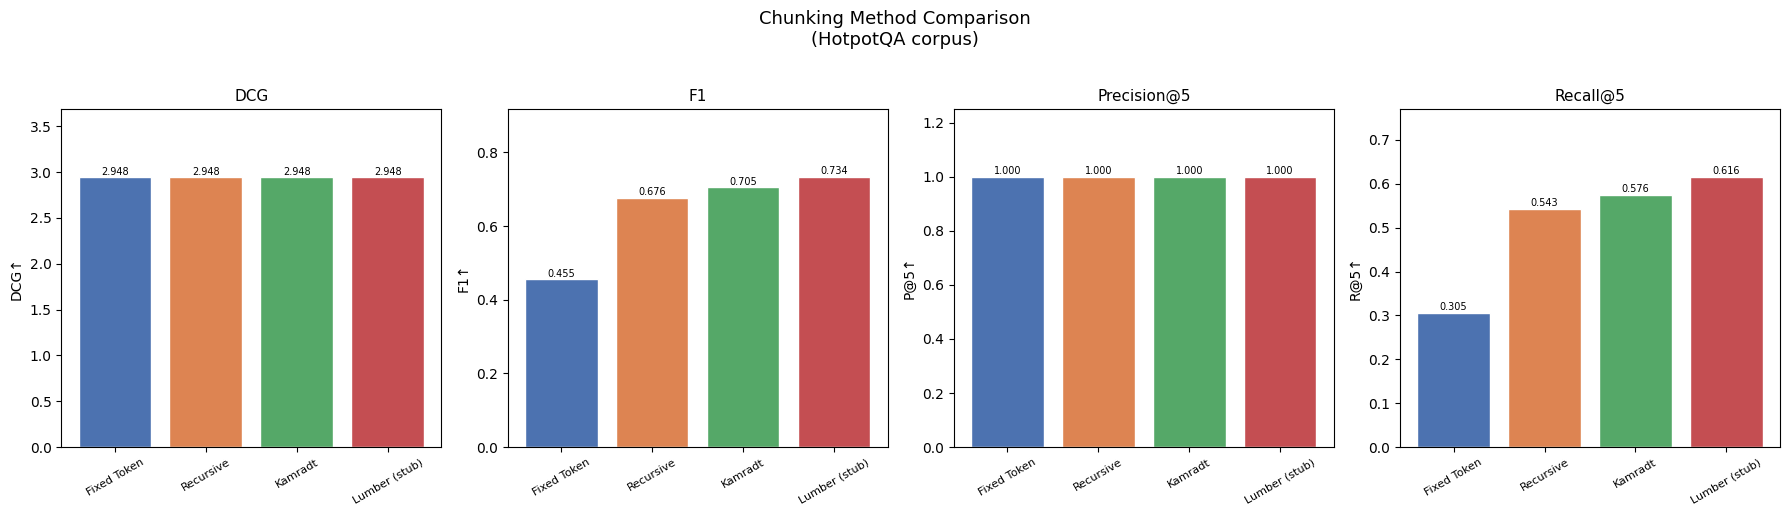

Figure saved to chunking_comparison.png


In [21]:
# ── Cell 11: Results visualisation ────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Chunking Method Comparison\n(HotpotQA corpus)", fontsize=13, y=1.02)

metrics_plot = [("DCG↑", "DCG"), ("F1↑", "F1"),
                ("P@5↑", "Precision@5"), ("R@5↑", "Recall@5")]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

for ax, (col, label) in zip(axes, metrics_plot):
    values  = df[col].values
    chunkers = df.index.tolist()
    bars = ax.bar(chunkers, values, color=colors[:len(chunkers)], edgecolor="white")
    ax.set_title(label, fontsize=11)
    ax.set_ylabel(col)
    ax.set_ylim(0, max(values) * 1.25 if max(values) > 0 else 1)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("chunking_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to chunking_comparison.png")

In [22]:
# ── Cell 12: DSC chunk-length ablation (Figure 4 in the paper) ────────────────
#
# Reproduce the paper's experiment: vary max_tokens for DSC and observe how
# DCG, F1, Precision, and Recall change (paper Fig. 4).
# ─────────────────────────────────────────────────────────────────────────────

token_range = [30, 50, 75, 100, 150, 200, 250, 300]
ablation_rows = []

print("Running DSC chunk-length ablation …")
for max_tok in tqdm(token_range, desc="max_tokens"):
    metrics = evaluate_chunker(
        dual_semantic_chunker, corpus_text, gold_standard,
        k=TOP_K,
        chunker_kwargs={"min_tokens": 10, "max_tokens": max_tok,
                        "d": DSC_D, "k": DSC_K},
    )
    metrics["max_tokens"] = max_tok
    ablation_rows.append(metrics)
    print(f"  max_tokens={max_tok:>4}  DCG={metrics['dcg']:.3f}  "
          f"F1={metrics['f1']:.3f}  P@5={metrics['precision']:.3f}  "
          f"R@5={metrics['recall']:.3f}  avg_len={metrics['avg_chunk_len']:.1f}")

abl_df = pd.DataFrame(ablation_rows).set_index("max_tokens")

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel("Max tokens per chunk")
ax1.set_title("DSC: chunk length impact on retrieval quality (replication of Fig. 4)")

for metric, ls in [("dcg", "-"), ("f1", "--"), ("precision", ":")]:
    ax1.plot(abl_df.index, abl_df[metric], marker="o", linestyle=ls, label=metric.upper())

ax2 = ax1.twinx()
ax2.plot(abl_df.index, abl_df["recall"], marker="s", linestyle="-.", color="gray", label="Recall")
ax2.set_ylabel("Recall", color="gray")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

ax1.set_ylabel("DCG / F1 / Precision")
plt.tight_layout()
plt.savefig("dsc_ablation_chunk_length.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to dsc_ablation_chunk_length.png")

Running DSC chunk-length ablation …


max_tokens:   0%|          | 0/8 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ── Cell 13: DSC — visualise similarity matrix and threshold ──────────────────
#
# Inspect the internal state of DSC for a short sample passage.
# This helps understand how θ is derived and where splits happen.
# ─────────────────────────────────────────────────────────────────────────────

SAMPLE_TEXT = corpus_text[2000:5000]   # ~750 tokens — pick a more interesting window

# Re-run Step 1→5 of DSC to expose internals
blocks_vis   = _spacy_blocks(SAMPLE_TEXT)
embs_vis     = embed_texts(blocks_vis)
S_vis        = (embs_vis @ embs_vis.T).astype(np.float64)

d_vis, k_vis = DSC_D, DSC_K
T_vis = [float(S_vis[i, j]) for i in range(len(blocks_vis))
                              for j in range(i + 1, min(i + d_vis, len(blocks_vis)))]
mu_vis    = float(np.mean(T_vis))
sigma_vis = float(np.std(T_vis))
theta_vis = min(mu_vis + k_vis * sigma_vis, 0.999)

print(f"Blocks   : {len(blocks_vis)}")
print(f"μ_T      : {mu_vis:.4f}")
print(f"σ_T      : {sigma_vis:.4f}")
print(f"θ = μ + {k_vis}·σ = {theta_vis:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: similarity matrix ────────────────────────────────────────────────────
im = axes[0].imshow(S_vis, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=axes[0])
axes[0].set_title(f"Cosine similarity matrix ({len(blocks_vis)} blocks)")
axes[0].set_xlabel("Block index")
axes[0].set_ylabel("Block index")

# Draw diagonal band
for delta in range(1, d_vis):
    for i in range(len(blocks_vis) - delta):
        axes[0].add_patch(plt.Rectangle(
            (i + delta - 0.5, i - 0.5), 1, 1,
            linewidth=0, facecolor="none", edgecolor="blue", alpha=0.0
        ))

# ── Right: consecutive similarities + threshold line ─────────────────────────
consec_sims = [float(S_vis[i, i + 1]) for i in range(len(blocks_vis) - 1)]
axes[1].bar(range(len(consec_sims)), consec_sims, color="steelblue", alpha=0.7)
axes[1].axhline(theta_vis, color="red", linestyle="--", linewidth=1.5,
                label=f"θ = {theta_vis:.3f}")
axes[1].set_title("Consecutive block similarities and threshold θ")
axes[1].set_xlabel("Block pair index")
axes[1].set_ylabel("Cosine similarity")
axes[1].legend()

plt.tight_layout()
plt.savefig("dsc_similarity_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


Embedding magnitude summary (raw embeddings):
               n_chunks_sampled  mean_l2  median_l2  std_l2  min_l2  max_l2  mean_abs_mean
chunker                                                                                   
Fixed Token                2000   3.1430     3.1483  0.1146  2.6477  3.4629         0.0870
Recursive                  2000   2.8832     2.8632  0.1773  2.3442  3.4485         0.0799
Kamradt                    2000   2.8106     2.8055  0.1492  2.3317  3.4098         0.0778
Lumber (stub)              2000   2.8964     2.8505  0.2243  2.4607  3.4485         0.0802


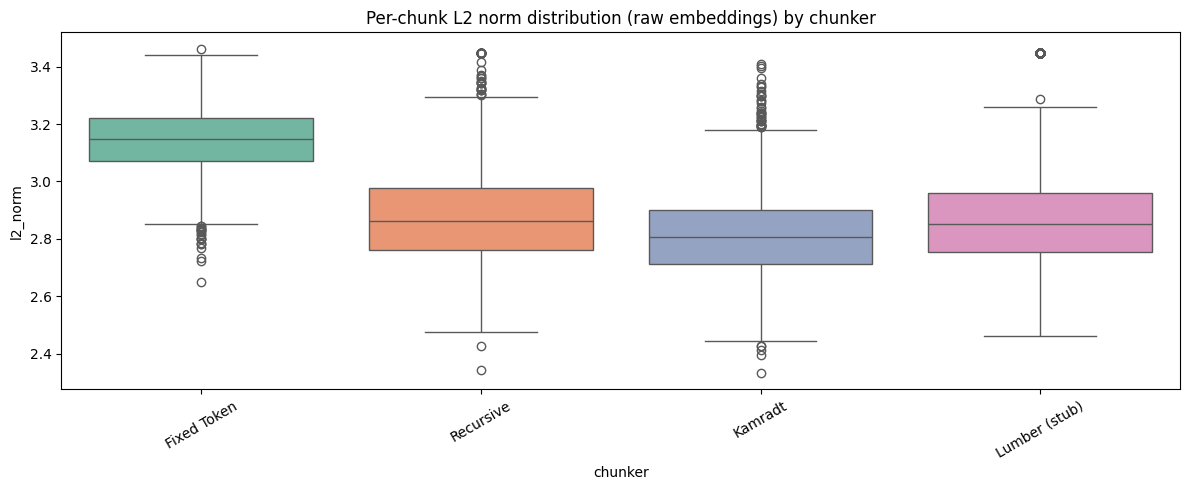

Figure saved to embedding_weights_comparison.png


In [23]:
# ── Cell 14: Embedding-weight comparison across chunkers ──────────────────────
#
# Compares raw (unnormalised) embedding magnitudes for chunks produced by
# each chunker. Computes per-chunk L2 norms and visualises distributions.
# Saves `embedding_weights_comparison.png` and prints a summary table.
#
import seaborn as sns

def embed_raw(texts, batch_size=64):
    """Return raw (unnormalised) embeddings from the shared `embed_model`."""
    vecs = embed_model.encode(texts, batch_size=batch_size,
                              show_progress_bar=False, normalize_embeddings=False)
    return np.asarray(vecs, dtype=np.float32)

rows = []
plot_data = []

for name, (fn, kwargs) in CHUNKERS.items():
    try:
        chunks = fn(corpus_text, **(kwargs or {}))
    except Exception as e:
        print(f"Chunker '{name}' error: {e} — skipping")
        continue

    if not chunks:
        print(f"Chunker '{name}' produced no chunks — skipping")
        continue

    # Subsample if too many chunks to keep plotting fast
    if len(chunks) > 2000:
        rng = np.random.default_rng(0)
        sample_idx = rng.choice(len(chunks), size=2000, replace=False)
        chunks_sample = [chunks[i] for i in sample_idx]
    else:
        chunks_sample = chunks

    vecs_raw = embed_raw(chunks_sample)
    l2_norms  = np.linalg.norm(vecs_raw, axis=1)
    mean_abs  = np.mean(np.abs(vecs_raw), axis=1)

    rows.append({
        "chunker": name,
        "n_chunks_sampled": len(chunks_sample),
        "mean_l2": float(np.mean(l2_norms)),
        "median_l2": float(np.median(l2_norms)),
        "std_l2": float(np.std(l2_norms)),
        "min_l2": float(np.min(l2_norms)),
        "max_l2": float(np.max(l2_norms)),
        "mean_abs_mean": float(np.mean(mean_abs)),
    })

    for v in l2_norms:
        plot_data.append({"chunker": name, "l2_norm": float(v)})

# DataFrame summary
if rows:
    emb_df = pd.DataFrame(rows).set_index("chunker")
    print("\nEmbedding magnitude summary (raw embeddings):")
    print(emb_df.round(4).to_string())

    # Plot distributions
    plt.figure(figsize=(12, 5))
    sns.boxplot(x="chunker", y="l2_norm", data=pd.DataFrame(plot_data), palette="Set2")
    plt.xticks(rotation=30)
    plt.title("Per-chunk L2 norm distribution (raw embeddings) by chunker")
    plt.tight_layout()
    plt.savefig("embedding_weights_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved to embedding_weights_comparison.png")
else:
    print("No embedding data collected. Ensure CHUNKERS and corpus_text are defined and chunkers executed.")